In [1]:
#Load data
#Misssing Values
#Class distribution
#Token count per class
#Most common words per class + bar chart


# Toxic Comment Classification

## Step 1 - Data Analysis

### 1.1 Load Data

In [2]:
import os
print(os.listdir('../data'))

['.DS_Store', 'test_labels.csv', 'test.csv', 'jigsaw-toxic-comment-classification-challenge', 'jigsaw-toxic-comment-classification-challenge.zip', 'train.csv', 'test.csv.zip', 'test_labels.csv.zip', 'train.csv.zip', 'sample_submission.csv.zip', 'sample_submission.csv']


In [3]:
import os
print(os.listdir('../data/jigsaw-toxic-comment-classification-challenge'))

['test_labels.csv', 'test.csv', 'train.csv', 'test.csv.zip', 'test_labels.csv.zip', 'train.csv.zip', 'sample_submission.csv.zip', 'sample_submission.csv']


In [4]:
import zipfile
import os

path = '../data'
for f in os.listdir(path):
    if f.endswith('.zip'):
        with zipfile.ZipFile(os.path.join(path, f), 'r') as z:
            z.extractall(path)
            print(f'Extracted: {f}')

Extracted: jigsaw-toxic-comment-classification-challenge.zip
Extracted: test.csv.zip
Extracted: test_labels.csv.zip
Extracted: train.csv.zip
Extracted: sample_submission.csv.zip


In [5]:
import pandas as pd

# download the data
toxic_df = pd.read_csv('../data/train.csv')

print(toxic_df .shape)
print(toxic_df .head())

(159571, 8)
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  


### 1.2 Class Distribution & Imbalance

In [45]:
toxic_df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [26]:
print(toxic_df.isnull().sum())

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
token_count      0
dtype: int64


### 1.3 Token Counts Per Class

In [8]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [46]:
import matplotlib.pyplot as plt

In [47]:
class_counts = toxic_df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].sum()

In [11]:
# Visualize the class data
class_counts.plot

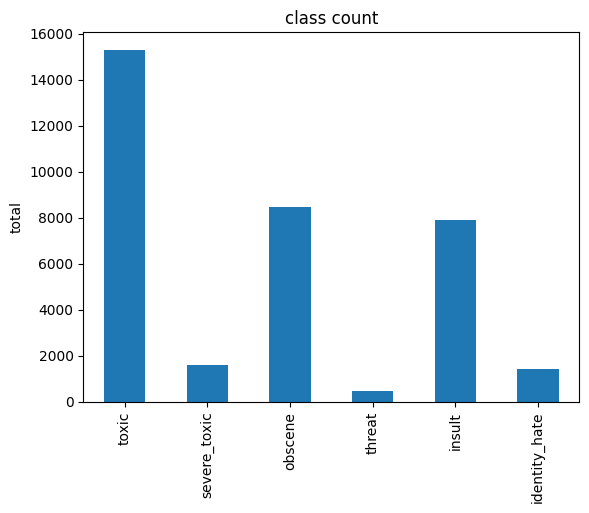

In [12]:
class_counts.plot(kind='bar')
plt.title('class count') 
plt.ylabel('total') 
plt.show()

In [48]:
# 
toxic_df['token_count'] = toxic_df['comment_text'].apply(lambda x: len(x.split()))

In [49]:
toxic_df['token_count'].head()

0     43
1     17
2     42
3    113
4     13
Name: token_count, dtype: int64

In [50]:
#  Calculating average for all classes data 
toxic_df[toxic_df['toxic'] == 1]['token_count'].mean()

51.28978684451419

In [51]:
toxic_df[toxic_df['severe_toxic'] == 1]['token_count'].mean()

75.62068965517241

In [52]:
toxic_df[toxic_df['obscene'] == 1]['token_count'].mean()

49.56053970884128

In [53]:
toxic_df[toxic_df['threat'] == 1]['token_count'].mean()

55.16527196652719

In [54]:
toxic_df[toxic_df['insult'] == 1]['token_count'].mean()

48.269264948584485

In [56]:
toxic_df[toxic_df['identity_hate'] == 1]['token_count'].mean()

52.01423487544484

### 1.4 Most Common Words Per Class

In [57]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [58]:
#  ?
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jeannetteverahelsby/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [59]:
#  ?
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
#print(stop_words)

#### Toxic Class

In [60]:
toxic_text=''.join(toxic_df[toxic_df['toxic'] == 1]['comment_text'])

In [61]:
print(toxic_text[:200])

COCKSUCKER BEFORE YOU PISS AROUND ON MY WORKHey... what is it..
@ | talk .
What is it... an exclusive group of some WP TALIBANS...who are good at destroying, self-appointed purist who GANG UP any one 


In [62]:
toxic_words = toxic_text.lower().split()

In [63]:
print(toxic_words[:200])

['cocksucker', 'before', 'you', 'piss', 'around', 'on', 'my', 'workhey...', 'what', 'is', 'it..', '@', '|', 'talk', '.', 'what', 'is', 'it...', 'an', 'exclusive', 'group', 'of', 'some', 'wp', 'talibans...who', 'are', 'good', 'at', 'destroying,', 'self-appointed', 'purist', 'who', 'gang', 'up', 'any', 'one', 'who', 'asks', 'them', 'questions', 'abt', 'their', 'anti-social', 'and', 'destructive', '(non)-contribution', 'at', 'wp?', 'ask', 'sityush', 'to', 'clean', 'up', 'his', 'behavior', 'than', 'issue', 'me', 'nonsensical', 'warnings...bye!', "don't", 'look,', 'come', 'or', 'think', 'of', 'comming', 'back!', 'tosser.you', 'are', 'gay', 'or', 'antisemmitian?', 'archangel', 'white', 'tiger', 'meow!', 'greetingshhh!', 'uh,', 'there', 'are', 'two', 'ways,', 'why', 'you', 'do', 'erased', 'my', 'comment', 'about', 'ww2,', 'that', 'holocaust', 'was', 'brutally', 'slaying', 'of', 'jews', 'and', 'not', 'gays/gypsys/slavs/anyone...', '1', '-', 'if', 'you', 'are', 'anti-semitian,', 'than', 'shave'

In [64]:
import string

In [65]:
toxic_words_clean = [word.translate(str.maketrans('', '', string.punctuation)) for word in toxic_words if word not in stop_words and word != '']

In [66]:
print(toxic_words_clean[:20])

['cocksucker', 'piss', 'around', 'workhey', 'it', '', '', 'talk', '', 'it', 'exclusive', 'group', 'wp', 'talibanswho', 'good', 'destroying', 'selfappointed', 'purist', 'gang', 'one']


In [67]:
from collections import Counter
toxic_word_counts = Counter(toxic_words_clean)
print(toxic_word_counts.most_common(20))

[('fuck', 8096), ('', 5038), ('you', 4056), ('like', 3460), ('shit', 3422), ('nigger', 3255), ('fucking', 3144), ('wikipedia', 3124), ('suck', 2952), ('go', 2683), ('hate', 2598), ('u', 2511), ('ass', 2477), ('get', 2212), ('know', 2172), ('gay', 2136), ('page', 2049), ('die', 2021), ('fat', 1955), ('faggot', 1838)]


In [68]:
words = [pair[0] for pair in toxic_word_counts.most_common(20)]
counts = [pair[1] for pair in toxic_word_counts.most_common(20)]

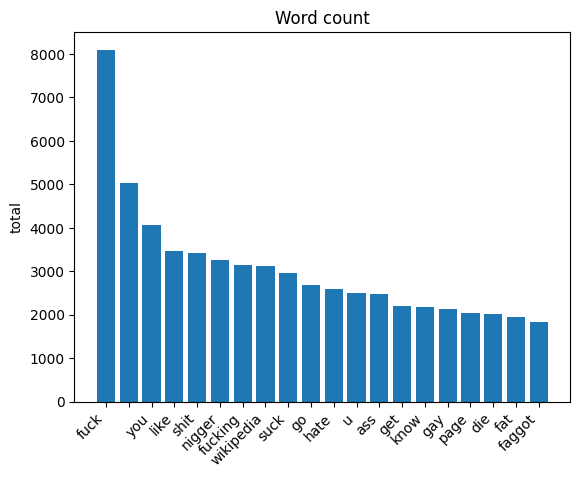

In [69]:
plt.bar(words, counts)
plt.title('Word count') 
plt.ylabel('total') 
plt.xticks(rotation=45, ha='right')
plt.show()

#### Severe Toxic class

In [70]:
# Most common words per class + bar char
# Severe toxic

In [71]:
stoxic_text=' '.join(toxic_df[toxic_df['severe_toxic'] == 1]['comment_text'])
stoxic_words = stoxic_text.lower().split()

In [72]:
print(stoxic_words[:200])

['cocksucker', 'before', 'you', 'piss', 'around', 'on', 'my', 'work', 'stupid', 'peace', 'of', 'shit', 'stop', 'deleting', 'my', 'stuff', 'asshole', 'go', 'die', 'and', 'fall', 'in', 'a', 'hole', 'go', 'to', 'hell!', 'you', 'are', 'a', 'stupid', 'fuck', 'and', 'your', "mother's", 'cunt', 'stinks', 'hi', 'im', 'a', 'fucking', 'bitch.', '50.180.208.181', 'what', 'a', 'motherfucking', 'piece', 'of', 'crap', 'those', 'fuckheads', 'for', 'blocking', 'us!', '"you', 'know,', 'i', 'was', 'thinking...', 'nobody', 'really', 'attacked', 'me', 'before', 'i', 'revealed', 'my', 'age', 'here.', 'after', 'i', 'announced', 'that', 'i', 'was', '14,', 'i', 'was', 'subject', 'to', 'a', 'constant', 'storm', 'of', 'harassment', 'and', 'abuse.', 'the', 'same', 'thing', 'goes', 'for', 'when', 'i', 'was', 'on', 'the', 'sandbox', 'when', 'i', 'was', '11.', 'before', 'people', 'knew', 'my', 'age,', 'they', "didn't", 'care.', 'after', 'i', 'told', 'them', 'my', 'age,', 'they', 'hated', 'me.', "it's", 'just', 'so'

In [73]:
# stop words removal
stoxic_words_clean = [word.translate(str.maketrans('', '', string.punctuation)) for word in stoxic_words if word not in stop_words and word != '']

In [74]:
print(stoxic_words_clean[:200])

['cocksucker', 'piss', 'around', 'work', 'stupid', 'peace', 'shit', 'stop', 'deleting', 'stuff', 'asshole', 'go', 'die', 'fall', 'hole', 'go', 'hell', 'stupid', 'fuck', 'mothers', 'cunt', 'stinks', 'hi', 'im', 'fucking', 'bitch', '50180208181', 'motherfucking', 'piece', 'crap', 'fuckheads', 'blocking', 'us', 'you', 'know', 'thinking', 'nobody', 'really', 'attacked', 'revealed', 'age', 'here', 'announced', '14', 'subject', 'constant', 'storm', 'harassment', 'abuse', 'thing', 'goes', 'sandbox', '11', 'people', 'knew', 'age', 'care', 'told', 'age', 'hated', 'me', 'amusing', 'idiot', 'soapboxers', 'think', 'teenagers', 'responsible', 'decline', 'soapbox', 'like', 'ever', 'good', 'begin', 'with', 'funny', 'adults', 'dumbest', 'people', 'here', 'mauricio', 'chuppah', 'redneckgirl', 'pinky', 'scooby', 'gg', 'foreverlosttinkerbell', 'greenrabbit', 'starrocketsinflight', 'breerobinson', 'enigma72', 'cocainenightmares', 'tokyodome', 'chadochocinco', 'steve', 'lake', 'all', 'adults', 'teenage', '

In [75]:
from collections import Counter
st_word_counts = Counter(stoxic_words_clean)
print(st_word_counts.most_common(20))

[('fuck', 6046), ('suck', 2341), ('shit', 1877), ('ass', 1827), ('you', 1720), ('faggot', 1570), ('u', 1400), ('fucking', 1373), ('go', 1239), ('die', 1155), ('nigger', 1011), ('sucks', 961), ('yourself', 860), ('cunt', 832), ('bitch', 763), ('wikipedia', 681), ('cock', 679), ('', 656), ('fucksex', 624), ('yourselfgo', 621)]


In [76]:
swords = [pair[0] for pair in st_word_counts.most_common(20)]
scounts = [pair[1] for pair in st_word_counts.most_common(20)]

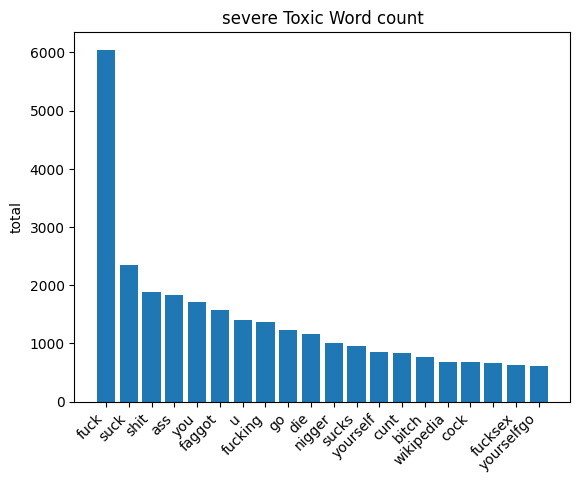

In [77]:
plt.bar(swords, scounts)
plt.title('severe Toxic Word count') 
plt.ylabel('total') 
plt.xticks(rotation=45, ha='right')
plt.show()

In [78]:
print(st_word_counts.most_common(5))

[('fuck', 6046), ('suck', 2341), ('shit', 1877), ('ass', 1827), ('you', 1720)]


In [79]:
print(st_word_counts.most_common(5))
print(type(st_word_counts))
print(len(st_word_counts))
print(len(stoxic_words_clean))
print(len(toxic_words_clean))

[('fuck', 6046), ('suck', 2341), ('shit', 1877), ('ass', 1827), ('you', 1720)]
<class 'collections.Counter'>
6321
79924
442332


In [80]:
print(len(stoxic_words_clean))
print(len(toxic_words_clean))

79924
442332


#### Obscene Class

In [81]:
obscene_text=' '.join(toxic_df[toxic_df['obscene'] == 1]['comment_text'])
obscene_words = obscene_text.lower().split()

In [82]:
# ?stop words
obscene_words_clean = [word.translate(str.maketrans('', '', string.punctuation)) for word in obscene_words if word not in stop_words]
obscene_words_clean = [word for word in obscene_words_clean if word != '']

In [83]:
#  ?????
obscene_word_counts = Counter(obscene_words_clean)
print(obscene_word_counts.most_common(20))

[('fuck', 8538), ('shit', 3183), ('fucking', 3097), ('you', 2852), ('suck', 2821), ('nigger', 2721), ('ass', 2517), ('go', 2117), ('u', 2056), ('wikipedia', 1635), ('like', 1526), ('cunt', 1517), ('get', 1399), ('bitch', 1392), ('fat', 1281), ('die', 1169), ('know', 1169), ('faggot', 1162), ('dick', 1143), ('bullshit', 1086)]


In [84]:
#  ?????
owords = [pair[0] for pair in st_word_counts.most_common(20)]
ocounts = [pair[1] for pair in st_word_counts.most_common(20)]

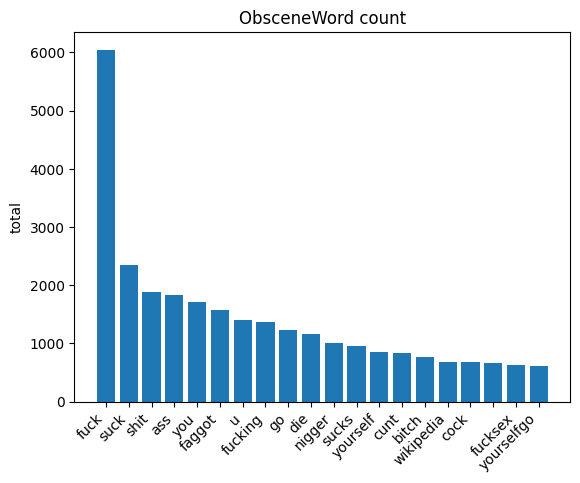

In [85]:
plt.bar(owords, ocounts)
plt.title('ObsceneWord count') 
plt.ylabel('total') 
plt.xticks(rotation=45, ha='right')
plt.show()

In [86]:
print(obscene_word_counts.most_common(5))
print(type(obscene_word_counts))
print(len(obscene_word_counts))
print(len(stoxic_words_clean))
print(len(toxic_words_clean))

[('fuck', 8538), ('shit', 3183), ('fucking', 3097), ('you', 2852), ('suck', 2821)]
<class 'collections.Counter'>
24224
79924
442332


In [87]:
#### Threat Class

In [88]:
thread_text = ''.join(toxic_df[toxic_df['threat'] == 1]['comment_text'])
thread_words = thread_text .lower().split()

In [89]:
thread_words_clean = [word.translate(str.maketrans('', '', string.punctuation)) for word in thread_words if word not in stop_words]
thread_words_clean = [word for word in thread_words_clean if word != '']

In [90]:
thread_words_count = Counter(thread_words_clean)
print(thread_words_count.most_common(20))

[('die', 1140), ('ass', 760), ('you', 594), ('kill', 502), ('going', 294), ('block', 169), ('must', 166), ('wales', 157), ('jim', 157), ('supertr0ll', 146), ('fucking', 135), ('ban', 131), ('page', 128), ('fuck', 117), ('wikipedia', 116), ('talk', 110), ('murder', 106), ('fuckin', 101), ('live', 98), ('rvv', 96)]


In [91]:
twords = [pair[0] for pair in thread_words_count.most_common(20)]
tcounts = [pair[1] for pair in thread_words_count.most_common(20)]

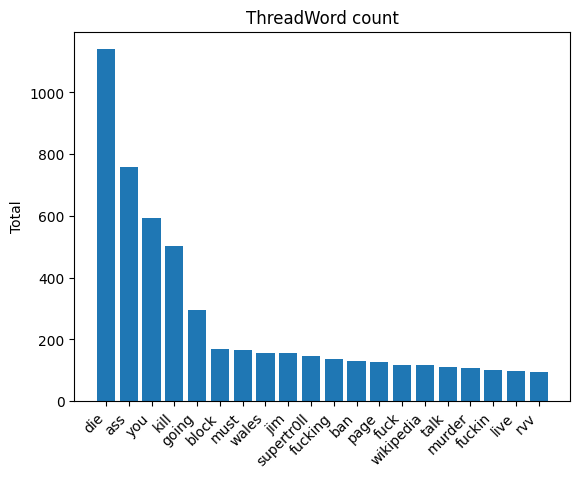

In [92]:
plt.bar(twords, tcounts)
plt.title('ThreadWord count') 
plt.ylabel('Total') 
plt.xticks(rotation=45, ha='right')
plt.show()

#### Insult Class

In [93]:
# insult
insult_text= ''.join(toxic_df[toxic_df['insult']== 1]['comment_text'])
insult_words=insult_text.lower().split()

In [94]:
insult_words_clean = [word.translate(str.maketrans('', '', string.punctuation)) for word in insult_words if word not in stop_words ]
insult_words_clean = [word for word in insult_words_clean if word != '']

In [95]:
insult_words_count = Counter(insult_words_clean)
print(insult_words_count.most_common(20))

[('fuck', 6173), ('nigger', 2745), ('fucking', 2668), ('suck', 2534), ('you', 2100), ('go', 2083), ('fat', 1912), ('u', 1907), ('ass', 1797), ('faggot', 1696), ('shit', 1555), ('like', 1539), ('moron', 1415), ('hate', 1377), ('hi', 1347), ('cunt', 1316), ('jew', 1291), ('get', 1253), ('die', 1185), ('wikipedia', 1183)]


In [96]:
iwords = [pair[0] for pair in insult_words_count.most_common(20)]
icounts = [pair[1] for pair in insult_words_count.most_common(20)]

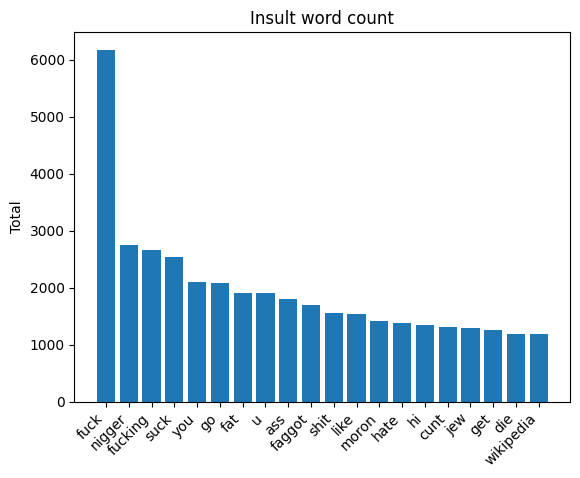

In [97]:
plt.bar(iwords,icounts)
plt.title('Insult word count')
plt.ylabel('Total')
plt.xticks(rotation=45, ha='right')
plt.show()

#### Identity_Hate Class

In [98]:
#1st text
hate_text= ' '.join(toxic_df[toxic_df['identity_hate']==1]['comment_text'])
#1st words
hate_words= hate_text.lower().split()

In [99]:
#Clean
hate_words_clean= [ word.translate(str.maketrans('', '', string.punctuation))   for word in hate_words if word not in stop_words ]
hate_words_clean = [ word for word in hate_words_clean if word != '' ]

In [100]:
hate_words_count = Counter(hate_words_clean)
print(hate_words_count .most_common(20))

[('nigger', 2963), ('fat', 1321), ('jew', 1307), ('gay', 911), ('die', 879), ('fuck', 875), ('faggot', 685), ('fucking', 518), ('huge', 429), ('suck', 426), ('shit', 406), ('stupid', 396), ('cunt', 392), ('like', 382), ('ass', 368), ('mexicans', 365), ('bitch', 345), ('niggas', 342), ('hate', 289), ('go', 284)]


In [101]:
hwords = [ pair[0] for pair in hate_words_count.most_common(20)]
hcounts = [ pair[1] for pair in hate_words_count.most_common(20)]

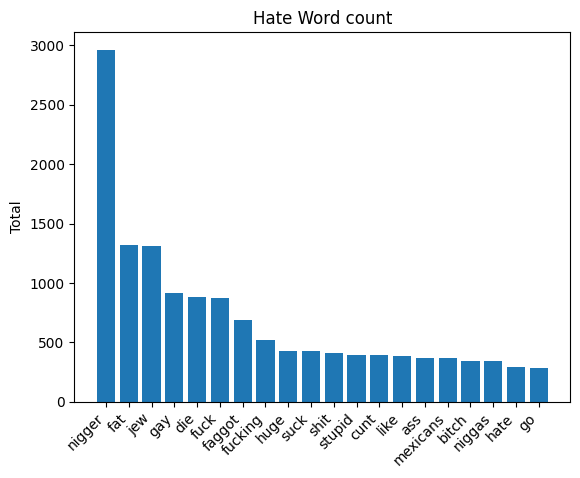

In [102]:
plt.bar(hwords,hcounts)
plt.title('Hate Word count')
plt.ylabel('Total')
plt.xticks(rotation=45, ha='right')
plt.show()

## Step 2. Feature Extraction & Models - TF-IDF

In [103]:
# Step 2 — TF-IDF
# TF-IDF stands for Term Frequency - Inverse Document Frequency.
# It's a way to convert text into numbers that a machine learning model can understand.
# TF-IDF tells you: "how important is this word to this specific comment?"

###  2.1 — TF-IDF

In [104]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [105]:
#You have 6 labels — toxic, severe_toxic, obscene, threat, insult, identity_hate.
#This is a multi-label problem — one comment can belong to multiple classes at the same time.
#For simplicity, for your first model (Logistic Regression), we'll focus on just one label at a time — starting with toxic.

In [106]:
X = toxic_df['comment_text']
y = toxic_df['toxic'] 

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [108]:
#Line 1 — create the TF-IDF tool, limit to 10,000 most important words
#Line 2 — fit_transform on training data = learn the vocabulary from training data AND convert to numbers
#Line 3 — transform on test data = convert to numbers using the vocabulary learned from training (NOT fit again — why?)

vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [109]:
print(X_train_tfidf.shape)

(127656, 10000)


In [ ]:
#X_train, X_test — raw text split into train and test
#y_train, y_test — labels split into train and test
#X_train_tfidf, X_test_tfidf — text converted to numbers using TF-IDF


### 2.2 Logistic Regression

In [111]:
#import and create the Logistic Regression model
from sklearn.linear_model import LogisticRegression

In [112]:
lr_model = LogisticRegression()

In [113]:
#train in sklearn
lr_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [114]:
y_pred = lr_model.predict(X_test_tfidf)

In [115]:
#now evaluate the model
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1:', f1_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))

Accuracy: 0.9580448065173116
F1: 0.7395448356350904
Recall: 0.6220549738219895
Precision: 0.9117505995203837


In [116]:
from sklearn.metrics import roc_auc_score
y_pred_proba = lr_model.predict_proba(X_test_tfidf)[:, 1]
print('AUC:', roc_auc_score(y_test, y_pred_proba))

AUC: 0.9705580722048291


In [117]:
#Create the list for classes
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

#Define X 
X = toxic_df['comment_text']

for class_name in classes:
    #Inside loop: y, train_test_split, TF-IDF, fit model, predict, evaluate, print results
        try:
            print(f'\n--- {class_name} ---') 
            y = toxic_df[class_name]

            #train_test_split
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

            #TF-IDF
            vectorizer = TfidfVectorizer(max_features=10000)
            X_train_tfidf = vectorizer.fit_transform(X_train)
            X_test_tfidf = vectorizer.transform(X_test)

            lr_model = LogisticRegression()
    
            # train the model
            lr_model.fit(X_train_tfidf, y_train)

            #predict the model
            y_pred = lr_model.predict(X_test_tfidf)
    
            # evaluate the model
            print('Accuracy:', accuracy_score(y_test, y_pred))
            print('F1:', f1_score(y_test, y_pred))
            print('Recall:', recall_score(y_test, y_pred))
            print('Precision:', precision_score(y_test, y_pred))
    
            y_pred_proba = lr_model.predict_proba(X_test_tfidf)[:, 1]
            print('AUC:', roc_auc_score(y_test, y_pred_proba))
            
        except Exception as e:
          print(f'Error for {class_name}: {e}')


--- toxic ---
Accuracy: 0.9580448065173116
F1: 0.7395448356350904
Recall: 0.6220549738219895
Precision: 0.9117505995203837
AUC: 0.9705580722048291

--- severe_toxic ---
Accuracy: 0.9906313645621181
F1: 0.3542116630669546
Recall: 0.2554517133956386
Precision: 0.5774647887323944
AUC: 0.978836038310835

--- obscene ---
Accuracy: 0.9765627447908507
F1: 0.7411764705882353
Recall: 0.6244897959183674
Precision: 0.9114893617021277
AUC: 0.9822944413337709

--- threat ---
Accuracy: 0.9975560081466395
F1: 0.1875
Recall: 0.12162162162162163
Precision: 0.4090909090909091
AUC: 0.9752787711237508

--- insult ---
Accuracy: 0.970797430675231
F1: 0.6448170731707317
Recall: 0.5241635687732342
Precision: 0.8376237623762376
AUC: 0.9761766464003645

--- identity_hate ---
Accuracy: 0.9916340278865737
F1: 0.2644628099173554
Recall: 0.16326530612244897
Precision: 0.6956521739130435
AUC: 0.9658826466610174


### 2.3 SVM

In [118]:
from sklearn.svm import LinearSVC

In [119]:
svm_model = LinearSVC(C=1, max_iter=1000)

In [ ]:

#SVM -Same steps as Logistic Regression:
#Define classes list
#Define X outside loop
#Loop through classes
#Inside loop:
#print class name
#define y
#train_test_split
#TF-IDF
#create SVM model
#fit
#predict
#evaluate (accuracy, f1, recall, precision, AUC)
#try/except


In [120]:
# Create the list for classes
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Define X 
X = toxic_df['comment_text']

for class_name in classes:
    try:
        #print class name
        print(f'\n--- {class_name} ---') 
        
        #define y
        y = toxic_df[class_name]
        
        #train_test_split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        #TF-IDF
        vectorizer = TfidfVectorizer(max_features=10000)
        X_train_tfidf = vectorizer.fit_transform(X_train)
        X_test_tfidf = vectorizer.transform(X_test)
        
        #create SVM model
        svm_model = LinearSVC(C=1, max_iter=1000)
        
        #train
        svm_model.fit(X_train_tfidf, y_train)
        
        #predict
        y_pred = svm_model.predict(X_test_tfidf) 
        
        #evaluate (accuracy, f1, recall, precision, AUC)
        # evaluate the model
        print('Accuracy:', accuracy_score(y_test, y_pred))
        print('F1:', f1_score(y_test, y_pred))
        print('Recall:', recall_score(y_test, y_pred))
        print('Precision:', precision_score(y_test, y_pred))
        
        y_pred_proba = svm_model.decision_function(X_test_tfidf)
        print('AUC:', roc_auc_score(y_test, y_pred_proba))
        
    except Exception as e:
          print(f'Error for {class_name}: {e}')



--- toxic ---
Accuracy: 0.9617107942973523
F1: 0.7774134790528233
Recall: 0.6982984293193717
Precision: 0.876746096959737
AUC: 0.9669632559933485

--- severe_toxic ---
Accuracy: 0.9902553658154473
F1: 0.3480083857442348
Recall: 0.2585669781931464
Precision: 0.532051282051282
AUC: 0.9604442028012338

--- obscene ---
Accuracy: 0.9790067366442112
F1: 0.7804718217562254
Recall: 0.6944606413994169
Precision: 0.8908002991772626
AUC: 0.9764230301392082

--- threat ---
Accuracy: 0.9979946733510888
F1: 0.41818181818181815
Recall: 0.3108108108108108
Precision: 0.6388888888888888
AUC: 0.9705822936092086

--- insult ---
Accuracy: 0.9717060943130189
F1: 0.6780748663101605
Recall: 0.5892193308550185
Precision: 0.7984886649874056
AUC: 0.9680862586194762

--- identity_hate ---
Accuracy: 0.9922606924643584
F1: 0.3931203931203931
Recall: 0.272108843537415
Precision: 0.7079646017699115
AUC: 0.9521710363409144


#### 2.4 MLP

In [121]:
from sklearn.neural_network import MLPClassifier

In [123]:
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Define X 
X = toxic_df['comment_text']
for class_name  in classes:
    try:
        #print class name
        print(f'\n--- {class_name} ---') 
        
        #define y
        y = toxic_df[class_name]
        
        #train_test_split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        #TF-IDF
        vectorizer = TfidfVectorizer(max_features=10000)
        X_train_tfidf = vectorizer.fit_transform(X_train)
        X_test_tfidf = vectorizer.transform(X_test)
        
        #create MLP model
        clf = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', max_iter=100, random_state=42)
        
        #fit
        clf.fit(X_train_tfidf, y_train)
        
        #predict
        y_pred = clf.predict(X_test_tfidf)
        
        #evaluate (accuracy, f1, recall, precision, AUC)
        # evaluate the model
        print('Accuracy:', accuracy_score(y_test, y_pred))
        print('F1:', f1_score(y_test, y_pred))
        print('Recall:', recall_score(y_test, y_pred))
        print('Precision:', precision_score(y_test, y_pred))
        
        y_pred_proba = clf.predict_proba(X_test_tfidf)[:, 1]
        print('AUC:', roc_auc_score(y_test, y_pred_proba))
    except Exception as e:
          print(f'Error for {class_name}: {e}')
    
        
    



--- toxic ---
Accuracy: 0.9504621651261163
F1: 0.737419033383159
Recall: 0.7264397905759162
Precision: 0.7487352445193929
AUC: 0.9437004054194531

--- severe_toxic ---
Accuracy: 0.9879993733354222
F1: 0.37520391517128876
Recall: 0.3582554517133956
Precision: 0.3938356164383562
AUC: 0.9479809743440778

--- obscene ---
Accuracy: 0.9754660817797274
F1: 0.7543144022591779
Recall: 0.7008746355685131
Precision: 0.8165760869565217
AUC: 0.9616498754657965

--- threat ---
Accuracy: 0.9971173429421902
F1: 0.43902439024390244
Recall: 0.4864864864864865
Precision: 0.4
AUC: 0.9585418935470755

--- insult ---
Accuracy: 0.9688234372552091
F1: 0.6751550767221678
Recall: 0.6406443618339529
Precision: 0.7135955831608005
AUC: 0.9455310466767817

--- identity_hate ---
Accuracy: 0.9911640294532351
F1: 0.34418604651162793
Recall: 0.25170068027210885
Precision: 0.5441176470588235
AUC: 0.914716378313129


## 3. Feature Extraction & Models - Word Embeddings

In [124]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 20.9 MB/s  0:00:011.4 MB/s eta 0:00:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gensim]━━━━ 1/2 [gensim]
Note: you may need to restart the kernel to use updated packages.


### 3.1 Word Embeddings Vectorisation

In [133]:
from gensim.models import Word2Vec

In [134]:
# Clean up
sentences = [comment.lower().split() for comment in toxic_df['comment_text']]

In [135]:
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [136]:
print(w2v_model.wv['toxic'])

[-0.0336305   0.23659854  0.14048705  0.25274032  0.27736083 -0.09343044
 -0.21976376  0.6966193  -0.15194269  0.10199023 -0.03346742 -0.5701484
  0.11641961  0.28153276  0.04629416 -0.42630148  0.16850416 -0.1446549
  0.0016122  -0.4062155   0.26148403  0.17192675  0.15394488 -0.18713652
 -0.05546454 -0.19028345 -0.21084091 -0.21633317 -0.05067286  0.23273532
  0.10623239  0.09744759  0.51340926 -0.16476794 -0.04479631  0.23354448
  0.03395185 -0.06192013 -0.23504013 -0.5038558   0.34768018 -0.26375633
 -0.34697184 -0.11463805  0.33888823 -0.22675678 -0.2762366   0.03019239
 -0.01131453  0.35743162  0.14874227 -0.2593672  -0.08376919 -0.11674546
 -0.18856679  0.31001493  0.13403925 -0.16150786 -0.21597816  0.12712932
  0.4050859   0.15681115 -0.07448246 -0.20233639 -0.37214655  0.08261042
  0.00827262  0.24917085 -0.26870498  0.39252123 -0.04395044  0.04868397
  0.2634072  -0.02418195  0.17723618  0.17030767  0.24758613 -0.03902995
 -0.01334927 -0.17927204 -0.30538076 -0.00232026 -0.3

In [144]:
import numpy as np
def getCommentVector(comment):
    """
    Converts a single commnet into averaged Word2Vec vector
    @param comment: Raw text for a single comment
    @return: a 100 vector if no words were recognized
    """
    
    # split comment into words
    words = comment.lower().split()
          
    # get vector for each word
    vectors = [ w2v_model.wv[word] for word in words if word in w2v_model.wv]
       
    # average all vectors
    if len (vectors) == 0:
        return np.zeros(100)
        
     # return the average vector
    return np.mean (vectors, axis=0)


In [145]:
print(getCommentVector("I hate food"))

[ 1.72745660e-01  5.29642344e-01 -1.41143367e-01 -4.89380091e-01
  1.42493820e+00  5.00264406e-01  1.37129009e+00 -2.50101119e-01
  5.98855495e-01  6.86094284e-01 -5.93475401e-01 -5.49472988e-01
  1.19266045e+00  1.16024041e+00 -5.17787993e-01 -3.14057469e+00
 -1.23226404e-01 -5.38034797e-01 -1.71678245e-01 -1.17301512e+00
 -4.69010621e-01 -7.75422394e-01  6.05753899e-01  8.19847286e-01
  3.84010702e-01 -1.79900467e+00  5.96788645e-01 -4.17227596e-01
 -1.00493288e+00 -6.46899998e-01  1.01488316e+00 -7.67049372e-01
 -3.65885735e-01 -1.77648053e-01  6.54414713e-01 -2.67452121e-01
  7.51543045e-02 -1.14986396e+00  8.09601724e-01 -1.83780193e+00
 -7.49726474e-01  4.78781313e-01 -8.11571300e-01  4.78069395e-01
 -6.85563743e-01 -1.68039596e+00 -7.74481237e-01  3.46126467e-01
 -7.95957863e-01  8.95698846e-04  8.87838781e-01 -1.11337137e+00
 -6.27845451e-02 -3.47639471e-01 -3.27753991e-01  1.29315913e-01
  8.68668318e-01 -1.43678367e-01 -6.40438318e-01 -9.50950906e-02
  3.53084952e-01  8.14330

### 3.2 Logistic Regression

In [ ]:
X_w2v = np.array([getCommentVector(comment) for comment in toxic_df['comment_text']])

In [148]:
print(X_w2v.shape)

(159571, 100)


In [149]:
#Create the list for classes
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

#Define X 
X = toxic_df['comment_text']

for class_name in classes:
    #Inside loop: y, train_test_split, TF-IDF, fit model, predict, evaluate, print results
        try:
            print(f'\n--- {class_name} ---') 
            y = toxic_df[class_name]

            #train_test_split         
            X_train, X_test, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2, random_state=42)

            #create Logistic model
            lr_model = LogisticRegression()
    
            # train the model
            lr_model.fit(X_train, y_train)

            #predict the model
            y_pred = lr_model.predict(X_test)
    
            # evaluate the model
            print('Accuracy:', accuracy_score(y_test, y_pred))
            print('F1:', f1_score(y_test, y_pred))
            print('Recall:', recall_score(y_test, y_pred))
            print('Precision:', precision_score(y_test, y_pred))
    
            y_pred_proba = lr_model.predict_proba(X_test)[:, 1]
            print('AUC:', roc_auc_score(y_test, y_pred_proba))
            
        except Exception as e:
          print(f'Error for {class_name}: {e}')


--- toxic ---
Accuracy: 0.9351715494281686
F1: 0.5795570006096322
Recall: 0.4666230366492147
Precision: 0.7646112600536193
AUC: 0.9281031031632585

--- severe_toxic ---
Accuracy: 0.9897540341532195
F1: 0.2813186813186813
Recall: 0.19937694704049844
Precision: 0.47761194029850745
AUC: 0.9710265780580207

--- obscene ---
Accuracy: 0.9634654551151496
F1: 0.5642750373692078
Recall: 0.4402332361516035
Precision: 0.785639958376691
AUC: 0.9402493580213541

--- threat ---
Accuracy: 0.9974620084599718
F1: 0.0898876404494382
Recall: 0.05405405405405406
Precision: 0.26666666666666666
AUC: 0.9342497392024731

--- insult ---
Accuracy: 0.9612094626351245
F1: 0.4896949711459192
Recall: 0.3680297397769517
Precision: 0.7315270935960592
AUC: 0.9449787094843162

--- identity_hate ---
Accuracy: 0.9904433651887827
F1: 0.09495548961424333
Recall: 0.05442176870748299
Precision: 0.37209302325581395
AUC: 0.9247538394251472


### 3.3 SVM

In [150]:
# Create the list for classes
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Define X 
X = toxic_df['comment_text']

for class_name in classes:
    try:
        #print class name
        print(f'\n--- {class_name} ---') 
        
        #define y
        y = toxic_df[class_name]
        
        #train_test_split
        X_train, X_test, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2, random_state=42)
        
        #TF-IDF
        #vectorizer = TfidfVectorizer(max_features=10000)
        #X_train_tfidf = vectorizer.fit_transform(X_train)
        #X_test_tfidf = vectorizer.transform(X_test)
        
        
        #create SVM model
        #undersyand parameters
        svm_model = LinearSVC(C=1, max_iter=300)
        
        #train
        svm_model.fit(X_train, y_train)
        
        #predict
        y_pred = svm_model.predict(X_test) 
        
        #evaluate (accuracy, f1, recall, precision, AUC)
        # evaluate the model
        print('Accuracy:', accuracy_score(y_test, y_pred))
        print('F1:', f1_score(y_test, y_pred))
        print('Recall:', recall_score(y_test, y_pred))
        print('Precision:', precision_score(y_test, y_pred))
        
        y_pred_proba = svm_model.decision_function(X_test)
        print('AUC:', roc_auc_score(y_test, y_pred_proba))
        
    except Exception as e:
          print(f'Error for {class_name}: {e}')



--- toxic ---
Accuracy: 0.9349208835970547
F1: 0.5553414686362663
Recall: 0.4244109947643979
Precision: 0.8030959752321981
AUC: 0.9278756590764737

--- severe_toxic ---
Accuracy: 0.9903806987310042
F1: 0.18997361477572558
Recall: 0.11214953271028037
Precision: 0.6206896551724138
AUC: 0.9726852785841864

--- obscene ---
Accuracy: 0.9628701237662541
F1: 0.5280764635603346
Recall: 0.3865889212827988
Precision: 0.8329145728643216
AUC: 0.9391883459154713

--- threat ---
Accuracy: 0.9976813410621964
F1: 0.0
Recall: 0.0
Precision: 0.0
AUC: 0.9378491270391651

--- insult ---


/Users/jeannetteverahelsby/Documents/Projects/Python-projects/toxic-comment-classifier/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.9605514648284506
F1: 0.4411895250776742
Recall: 0.30793060718711274
Precision: 0.7777777777777778
AUC: 0.9464927114800706

--- identity_hate ---
Accuracy: 0.9908193639354536
F1: 0.020066889632107024
Recall: 0.01020408163265306
Precision: 0.6
AUC: 0.9318918453185012


### 3.4 MLP

In [153]:
classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Define X 
X = toxic_df['comment_text']
for class_name  in classes:
    try:
        #print class name
        print(f'\n--- {class_name} ---') 
        
        #define y
        y = toxic_df[class_name]
        
        #train_test_split
        X_train, X_test, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2, random_state=42)
        
        #TF-IDF
        #vectorizer = TfidfVectorizer(max_features=10000)
        #X_train_tfidf = vectorizer.fit_transform(X_train)
        #X_test_tfidf = vectorizer.transform(X_test)
        
        #create MLP model
        clf = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', max_iter=100, random_state=42)
        
        #fit
        clf.fit(X_train, y_train)
        
        #predict
        y_pred = clf.predict(X_test)
        
        #evaluate (accuracy, f1, recall, precision, AUC)
        # evaluate the model
        print('Accuracy:', accuracy_score(y_test, y_pred))
        print('F1:', f1_score(y_test, y_pred))
        print('Recall:', recall_score(y_test, y_pred))
        print('Precision:', precision_score(y_test, y_pred))
        
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
        print('AUC:', roc_auc_score(y_test, y_pred_proba))
    except Exception as e:
          print(f'Error for {class_name}: {e}')


--- toxic ---


/Users/jeannetteverahelsby/Documents/Projects/Python-projects/toxic-comment-classifier/venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.9311608961303462
F1: 0.6059192825112107
Recall: 0.5526832460732984
Precision: 0.6705041683207622
AUC: 0.8942985156753299

--- severe_toxic ---


/Users/jeannetteverahelsby/Documents/Projects/Python-projects/toxic-comment-classifier/venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.9889393702020993
F1: 0.300990099009901
Recall: 0.2367601246105919
Precision: 0.41304347826086957
AUC: 0.9375463064578885

--- obscene ---


/Users/jeannetteverahelsby/Documents/Projects/Python-projects/toxic-comment-classifier/venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.9597368008773304
F1: 0.6107240230233263
Recall: 0.5877551020408164
Precision: 0.6355611601513241
AUC: 0.9039527831946401

--- threat ---
Accuracy: 0.997086009713301
F1: 0.2900763358778626
Recall: 0.25675675675675674
Precision: 0.3333333333333333
AUC: 0.9268158425691166

--- insult ---


/Users/jeannetteverahelsby/Documents/Projects/Python-projects/toxic-comment-classifier/venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.9578568071439761
F1: 0.5631698603442676
Recall: 0.5371747211895911
Precision: 0.5918088737201365
AUC: 0.9098322031814049

--- identity_hate ---
Accuracy: 0.987842707190976
F1: 0.245136186770428
Recall: 0.21428571428571427
Precision: 0.2863636363636364
AUC: 0.8447993314526405


/Users/jeannetteverahelsby/Documents/Projects/Python-projects/toxic-comment-classifier/venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
## 4. Results Comparison

In [ ]:
### 4.1 TF-IDF vs Word Embeddings

In [ ]:
### 4.2 Model Comparison Table

In [ ]:
### 4.3 Key Findings

In [ ]:
## 5. Kaggle Submission